In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


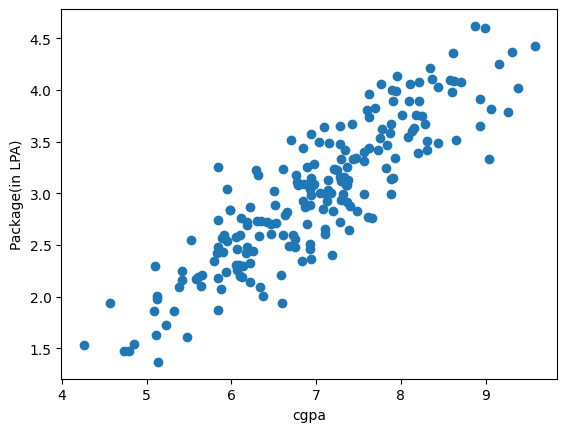

In [4]:
plt.scatter(x=df['cgpa'],y=df['package'])
plt.xlabel("cgpa")
plt.ylabel("Package(in LPA)")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]

In [7]:
X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=2, test_size=0.2)

In [8]:
X_train.shape

(160, 1)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr=LinearRegression()

In [11]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
X_test.iloc[0]

cgpa    8.58
Name: 112, dtype: float64

In [13]:
y_test.iloc[0]

np.float64(4.1)

In [14]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

c:\Users\DSingh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

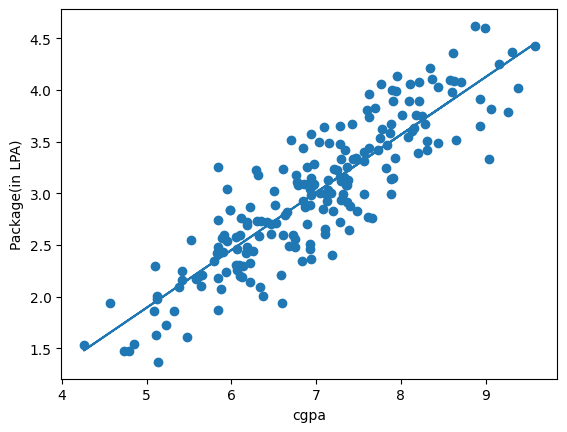

In [15]:
plt.scatter(x=df['cgpa'],y=df['package'])
plt.plot(X_train, lr.predict(X_train))
plt.xlabel("cgpa")
plt.ylabel("Package(in LPA)")
plt.show()

In [16]:
# slope
m=lr.coef_

## y=mx + c

# intercept
c=lr.intercept_

In [17]:
print(m,c,sep='\n')

[0.55795197]
-0.8961119222429144


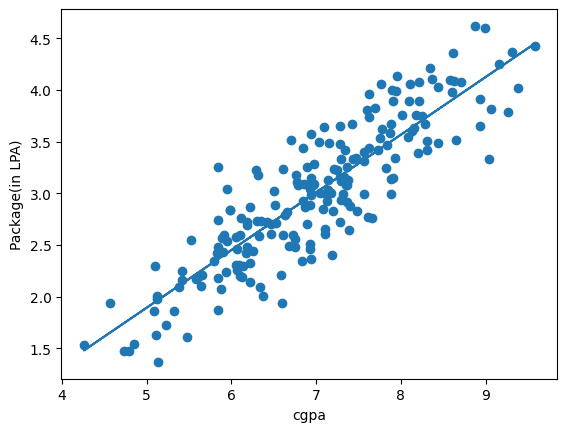

In [18]:
plt.scatter(x=df['cgpa'],y=df['package'])
plt.plot(df['cgpa'].values  ,  df['cgpa'].values*m +c)
plt.xlabel("cgpa")
plt.ylabel("Package(in LPA)")
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
y_pred=lr.predict(X_test)

In [21]:
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [23]:
print("MAE", mean_absolute_error(y_pred , y_test))

MAE 0.2884710931878175


In [24]:
print("MSE", mean_squared_error(y_pred , y_test))
 

MSE 0.12129235313495527


In [28]:
import numpy as np
print("RMSE", np.sqrt(mean_squared_error(y_pred , y_test)))


RMSE 0.34827051717731616


In [29]:
print("R2 score", r2_score(y_test , y_pred))


R2 score 0.780730147510384


In [30]:
print(X_test.shape)

(40, 1)


In [31]:
## Adjusted R2 score
r2=r2_score(y_test , y_pred)
k=1
1-((1-r2)*(40-1)/(40-1-k))

0.7749598882343415

In [32]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [33]:
new_df2.sample(5)

,cgpa,iq,package
193,4.57,1.44,1.94
14,7.73,3.92,3.42
114,5.84,0.67,1.87
190,6.19,1.89,2.69
47,5.84,2.76,3.26


Text(0, 0.5, 'Package(in lpa)')

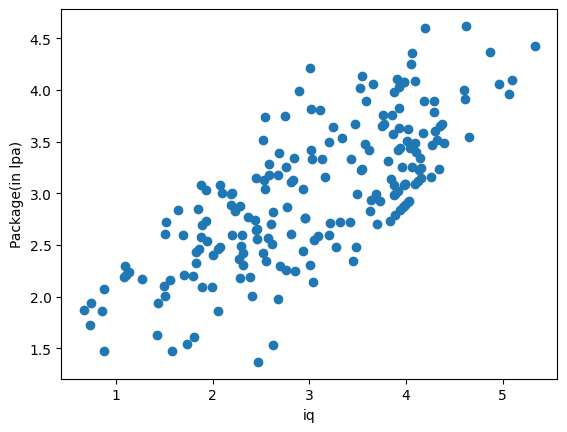

In [34]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [35]:
np.random.randint(-100,100)

5

In [36]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [38]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)


R2 score 0.8463283286692203


In [39]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8380217518405295